In [1]:
# 1. Cargar las tablas de datos en Pandas:

import pandas as pd

DIM_CATEGORY = pd.read_csv('DIM_CATEGORY (2).csv')
DIM_PRODUCT = pd.read_excel('DIM_PRODUCT (1).xlsx')
DIM_SEGMENT = pd.read_excel('DIM_SEGMENT (1).xlsx')
DIM_CALENDAR = pd.read_excel('DIM_CALENDAR (2).xlsx')
FACT_SALES = pd.read_csv('FACT_SALES (1).csv')

2. Identificar las variables clave para el análisis:

Las variables clave para el análisis se clasificaron en cinco grupos: ventas, producto, segmentación comercial, tiempo y región. Las variables de ventas (TOTAL_UNIT_SALES y TOTAL_VALUE_SALES) permiten medir el desempeño comercial en términos de volumen e ingresos. Las variables de producto y segmento facilitan la comparación entre categorías, formatos y segmentos de mercado. Las variables temporales permiten identificar tendencias y patrones estacionales, mientras que la variable región permite analizar diferencias geográficas en el comportamiento de ventas.

In [2]:
# 3. Visualizar la distribución de ventas: Crea gráficos de distribución (histogramas o boxplots) para visualizar la distribución de ventas por 
# diferentes categorías. Esto ayudará a identificar patrones de ventas y posibles outliers.

import pandas as pd
import matplotlib.pyplot as plt

FACT_SALES.head()
DIM_PRODUCT.head()
DIM_CATEGORY.head()

,ID_CATEGORY,CATEGORY
0,1,FABRIC TREATMENT and SANIT\r\n
1,2,AIR CARE
2,3,LAVAVAJILLAS
3,4,MEGA SUPERFICIES
4,5,LAVATORY CARE & BRC


In [3]:
# Unir ventas con productos para obtener la categoría
sales_product = FACT_SALES.merge(DIM_PRODUCT[['ITEM', 'CATEGORY']], left_on = 'ITEM_CODE', right_on = 'ITEM', how ='left')

# Unir con la tabla de categorías para obtener el nombre
sales_category = sales_product.merge(DIM_CATEGORY, left_on = 'CATEGORY',  right_on = 'ID_CATEGORY', how = 'left')

# Verificar resultado
sales_category = sales_category.rename(columns = {'CATEGORY_y': 'CATEGORY_NAME'})

sales_category[['TOTAL_UNIT_SALES', 'CATEGORY_NAME']].head()

,TOTAL_UNIT_SALES,CATEGORY_NAME
0,0.006,FABRIC TREATMENT and SANIT\r\n
1,0.487,FABRIC TREATMENT and SANIT\r\n
2,1.391,FABRIC TREATMENT and SANIT\r\n
3,0.022,FABRIC TREATMENT and SANIT\r\n
4,2.037,FABRIC TREATMENT and SANIT\r\n


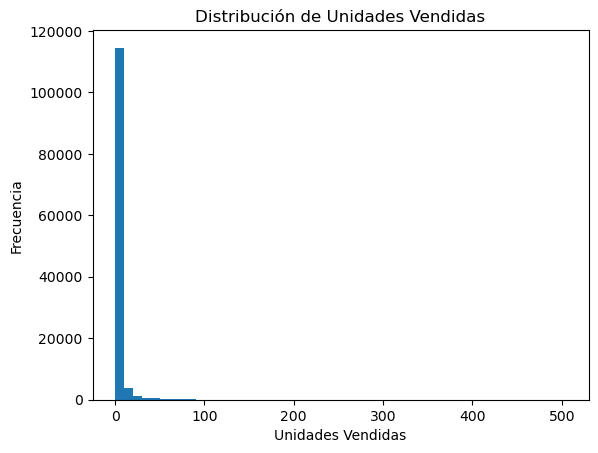

In [4]:
# Histograma: distribución general de ventas

plt.figure()
plt.hist(sales_category['TOTAL_UNIT_SALES'], bins=50)
plt.title('Distribución de Unidades Vendidas')
plt.xlabel('Unidades Vendidas')
plt.ylabel('Frecuencia')
plt.savefig('Distribución de Unidades Vendidas.png', dpi=300, bbox_inches="tight")
plt.show()

) missing from font(s) DejaVu Sans.mp\ipykernel_17024\3246746170.py:9: UserWarning: Glyph 13 (
  plt.savefig('Distribución de Unidades Vendidas por Categoría esc. 500.png', dpi=300, bbox_inches="tight")


<Figure size 1000x600 with 0 Axes>

) missing from font(s) DejaVu Sans.te-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 13 (
  fig.canvas.print_figure(bytes_io, **kw)


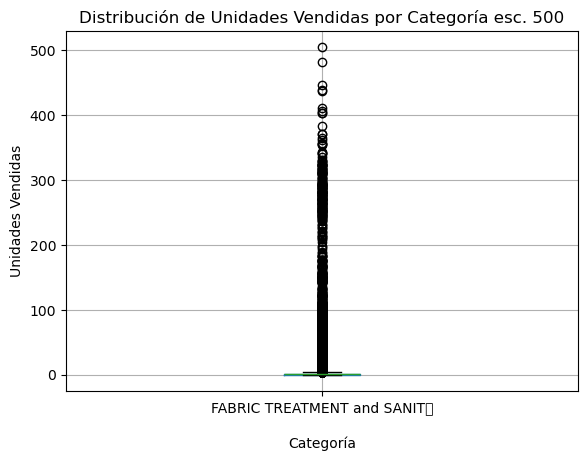

In [5]:
# Boxplot: ventas por categoría (detección de outliers)

plt.figure(figsize = (10,6))
sales_category.boxplot(column = 'TOTAL_UNIT_SALES', by = 'CATEGORY_NAME')
plt.title('Distribución de Unidades Vendidas por Categoría esc. 500')
plt.suptitle('')
plt.xlabel('Categoría')
plt.ylabel('Unidades Vendidas')
plt.savefig('Distribución de Unidades Vendidas por Categoría esc. 500.png', dpi=300, bbox_inches="tight")
plt.show()

Conclusión:
Los gráficos de distribución permiten observar que las ventas presentan una distribución asimétrica, con la presencia de valores atípicos en algunas categorías, lo que indica productos con picos de ventas significativamente superiores al promedio. El boxplot por categoría evidencia diferencias en la dispersión de las ventas, lo que sugiere comportamientos comerciales distintos entre categorías de producto. Este análisis facilita la identificación de patrones de ventas y posibles oportunidades de optimización comercial.

In [6]:
import pathlib
pathlib.Path().resolve()

WindowsPath('C:/Users/980014097')

In [7]:
# MERGES NECESARIOS

sales_product = FACT_SALES.merge(DIM_PRODUCT[['ITEM', 'CATEGORY']], left_on = 'ITEM_CODE', right_on = 'ITEM', how = 'left')
sales_category = sales_product.merge(DIM_CATEGORY, left_on = 'CATEGORY', right_on = 'ID_CATEGORY', how = 'left')
sales_category.head()


,WEEK,ITEM_CODE,TOTAL_UNIT_SALES,TOTAL_VALUE_SALES,TOTAL_UNIT_AVG_WEEKLY_SALES,REGION,ITEM,CATEGORY_x,ID_CATEGORY,CATEGORY_y
0,34-22,7501058792808BP2,0.006,0.139,1.000,TOTAL AUTOS AREA 5,7501058792808BP2,1,1,FABRIC TREATMENT and SANIT\r\n
1,34-22,7501058715883,0.487,116.519,2.916,TOTAL AUTOS AREA 5,7501058715883,1,1,FABRIC TREATMENT and SANIT\r\n
2,34-22,7702626213774,1.391,68.453,5.171,TOTAL AUTOS AREA 5,7702626213774,1,1,FABRIC TREATMENT and SANIT\r\n
3,34-22,7501058716422,0.022,1.481,1.833,TOTAL AUTOS AREA 5,7501058716422,1,1,FABRIC TREATMENT and SANIT\r\n
4,34-22,7501058784353,2.037,182.839,5.375,TOTAL AUTOS AREA 5,7501058784353,1,1,FABRIC TREATMENT and SANIT\r\n


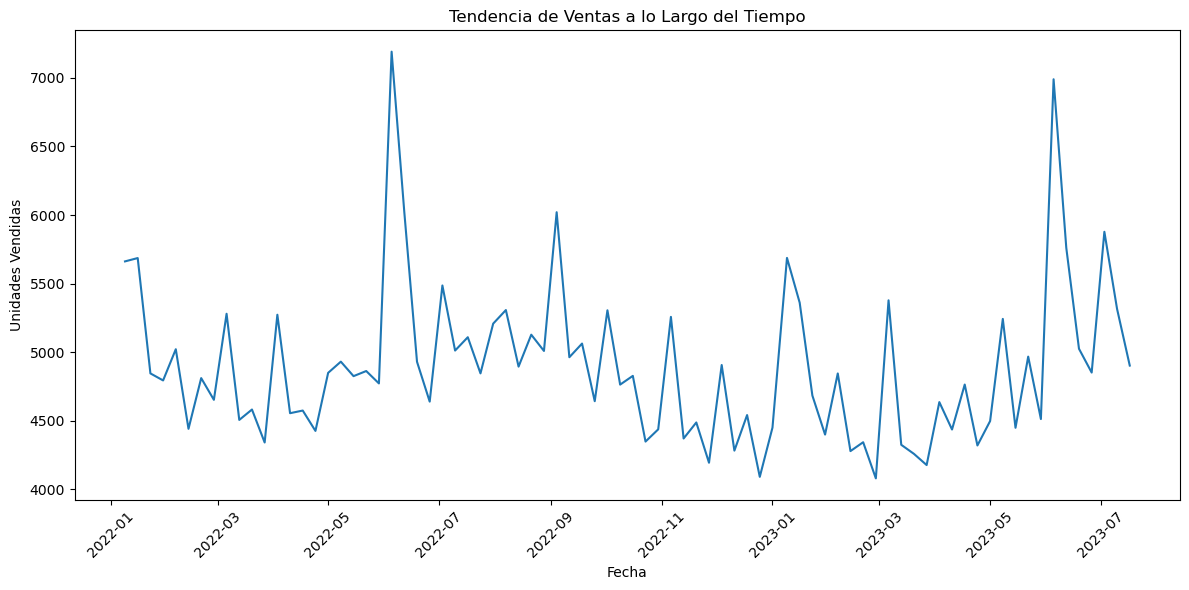

In [8]:
# 4. Analizar la tendencia de ventas en el tiempo: Genera gráficos de líneas que muestren las tendencias de ventas a lo largo del tiempo. 
# Filtra las ventas por diferentes productos, regiones o segmentos para analizar cómo han cambiado las ventas a lo largo del tiempo.

# Merge con calendario para obtener fecha real
sales_calendar = sales_category.merge(DIM_CALENDAR, on = 'WEEK', how = 'left')

sales_trend_date = sales_calendar.groupby('DATE')['TOTAL_UNIT_SALES'].sum().reset_index()

import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))
plt.plot(sales_trend_date['DATE'], sales_trend_date['TOTAL_UNIT_SALES'])
plt.xticks(rotation=45)
plt.title('Tendencia de Ventas a lo Largo del Tiempo')
plt.xlabel('Fecha')
plt.ylabel('Unidades Vendidas')
plt.tight_layout()
plt.savefig('Tendencia de Ventas a lo Largo del Tiempo.png', dpi=300, bbox_inches="tight")
plt.show()

) missing from font(s) DejaVu Sans.mp\ipykernel_17024\1416646778.py:20: UserWarning: Glyph 13 (
  plt.tight_layout()
) missing from font(s) DejaVu Sans.mp\ipykernel_17024\1416646778.py:21: UserWarning: Glyph 13 (
  plt.savefig('Tendencia_de_Ventas_por_Categoría_a_lo_Largo_del_Tiempo.png', dpi=300, bbox_inches="tight")
) missing from font(s) DejaVu Sans.te-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 13 (
  fig.canvas.print_figure(bytes_io, **kw)


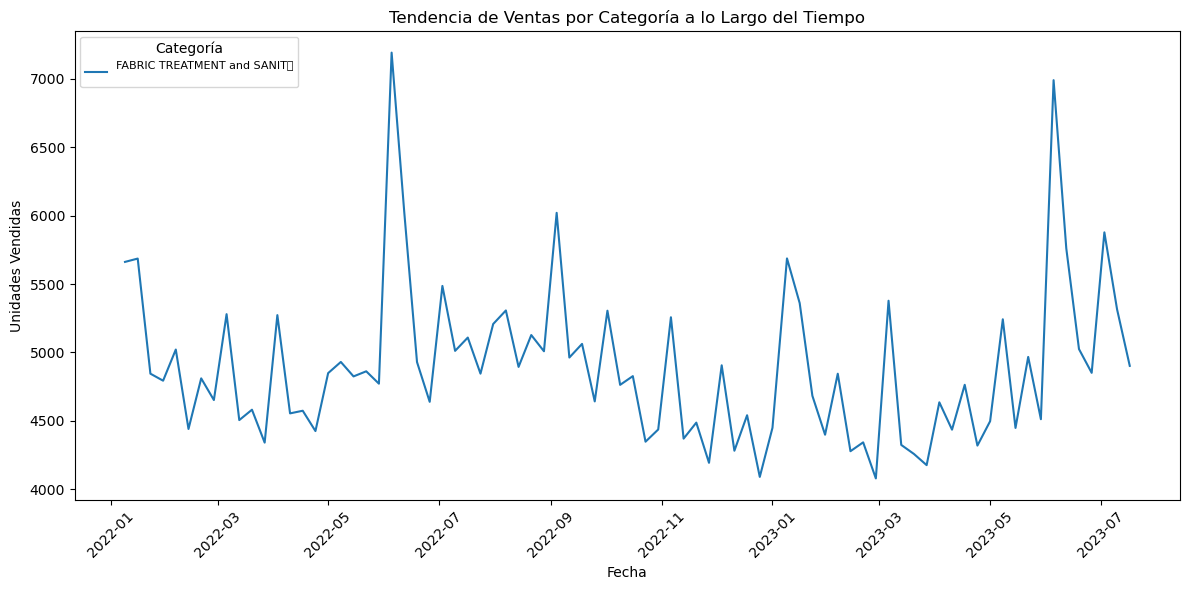

In [21]:
# Tendencia de ventas por categoría en el tiempo

# Merge con calendario para obtener DATE
sales_calendar = sales_category.merge(DIM_CALENDAR, on = 'WEEK', how = 'left')

# Agrupar por fecha y categoría
sales_cat_trend = sales_calendar.groupby(['DATE', 'CATEGORY_y'])['TOTAL_UNIT_SALES'].sum().reset_index()

# Gráfico de líneas por categoría
plt.figure(figsize=(12,6))

for cat in sales_cat_trend['CATEGORY_y'].unique():
    data = sales_cat_trend[sales_cat_trend['CATEGORY_y'] == cat]
    plt.plot(data['DATE'], data['TOTAL_UNIT_SALES'], label = cat)

plt.title('Tendencia de Ventas por Categoría a lo Largo del Tiempo')
plt.xlabel('Fecha')
plt.ylabel('Unidades Vendidas')
plt.xticks(rotation=45)
plt.legend(title='Categoría', fontsize=8)
plt.tight_layout()
plt.savefig('Tendencia_de_Ventas_por_Categoría_a_lo_Largo_del_Tiempo.png', dpi=300, bbox_inches="tight")
plt.show()

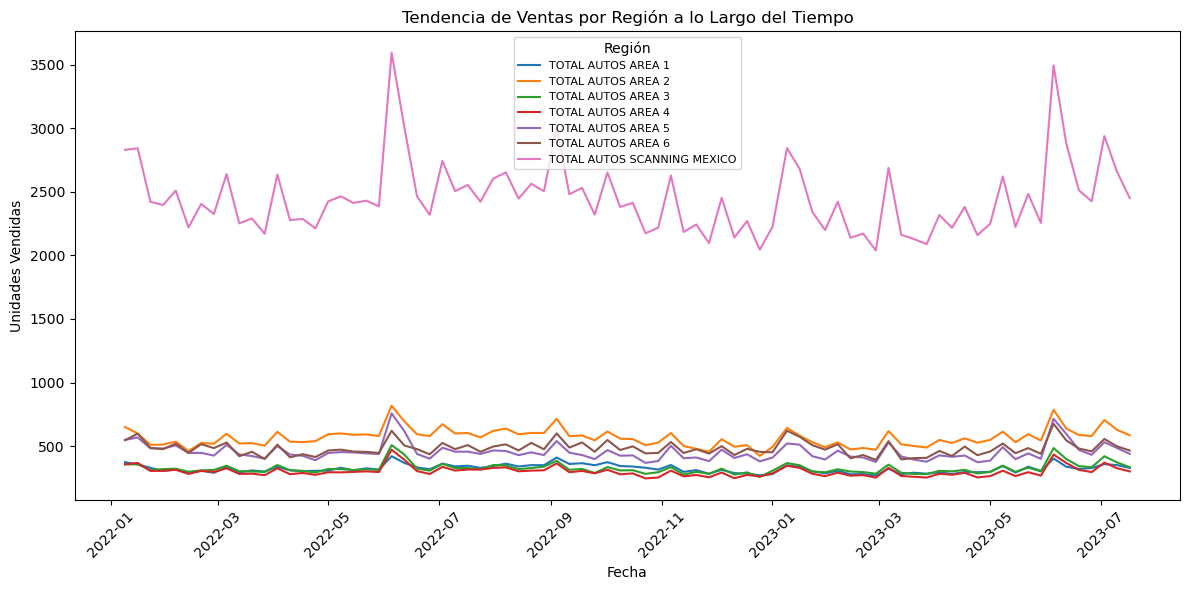

In [14]:
# Tendencia de ventas por región

# Merge con calendario para obtener DATE
sales_calendar = sales_category.merge(DIM_CALENDAR, on = 'WEEK', how = 'left')

# Agrupar por fecha y región
sales_region_trend = sales_calendar.groupby(['DATE', 'REGION'])['TOTAL_UNIT_SALES'].sum().reset_index()

# Gráfico de líneas por región
plt.figure(figsize=(12,6))

for reg in sales_region_trend['REGION'].unique():
    data = sales_region_trend[sales_region_trend['REGION'] == reg]
    plt.plot(data['DATE'], data['TOTAL_UNIT_SALES'], label = reg)

plt.title('Tendencia de Ventas por Región a lo Largo del Tiempo')
plt.xlabel('Fecha')
plt.ylabel('Unidades Vendidas')
plt.xticks(rotation=45)
plt.legend(title='Región', fontsize=8)
plt.tight_layout()
plt.savefig('Tendencia de Ventas por Región a lo Largo del Tiempo.png', dpi=300, bbox_inches="tight")
plt.show()

Análisis de tendencias:
El análisis temporal de las ventas muestra una variación significativa a lo largo de los meses analizados, lo que sugiere la presencia de picos y periodos de baja demanda. Al segmentar las ventas por categoría, se observan diferencias claras en el comportamiento de cada una, indicando que algunas categorías presentan mayor estabilidad mientras que otras muestran mayor volatilidad. Asimismo, el análisis por región permite identificar zonas con un desempeño consistentemente superior, lo cual representa oportunidades para fortalecer estrategias comerciales regionales.

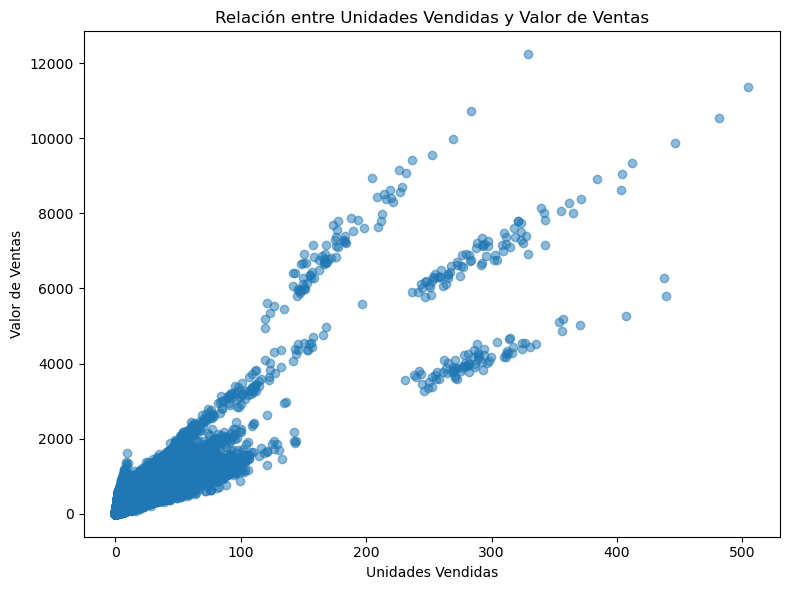

In [10]:
# 5. Explorar la relación entre diferentes variables: Utiliza gráficos de dispersión (scatter plots) para investigar relaciones entre variables clave.
# Esto puede ayudar a identificar correlaciones significativas entre diferentes variables.

# Relación entre unidades vendidas y valor de ventas
#Este scatter permite ver si a mayor volumen vendido corresponde mayor valor, y detectar posibles outliers.

import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))
plt.scatter(sales_category['TOTAL_UNIT_SALES'], sales_category['TOTAL_VALUE_SALES'], alpha = 0.5)

plt.title('Relación entre Unidades Vendidas y Valor de Ventas')
plt.xlabel('Unidades Vendidas')
plt.ylabel('Valor de Ventas')
plt.tight_layout()
plt.savefig('Relación entre Unidades Vendidas y Valor de Ventas.png', dpi=300, bbox_inches="tight")
plt.show()

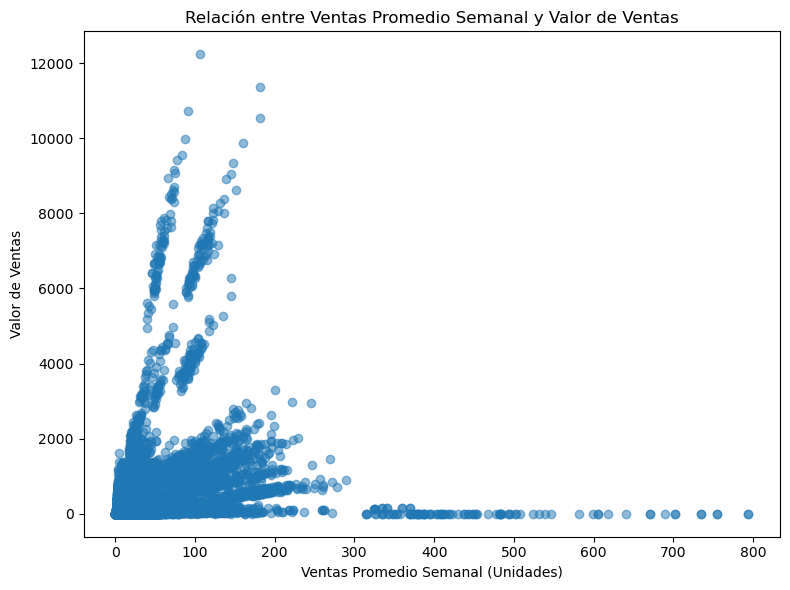

In [11]:
# Relación entre ventas promedio semanal y valor de ventas
# Ayuda a identificar si los productos con mejor desempeño promedio generan mayor valor económico.

plt.figure(figsize=(8,6))
plt.scatter(sales_category['TOTAL_UNIT_AVG_WEEKLY_SALES'], sales_category['TOTAL_VALUE_SALES'], alpha = 0.5)

plt.title('Relación entre Ventas Promedio Semanal y Valor de Ventas')
plt.xlabel('Ventas Promedio Semanal (Unidades)')
plt.ylabel('Valor de Ventas')
plt.tight_layout()
plt.savefig('Relación entre Ventas Promedio Semanal y Valor de Ventas.png', dpi=300, bbox_inches="tight")
plt.show()

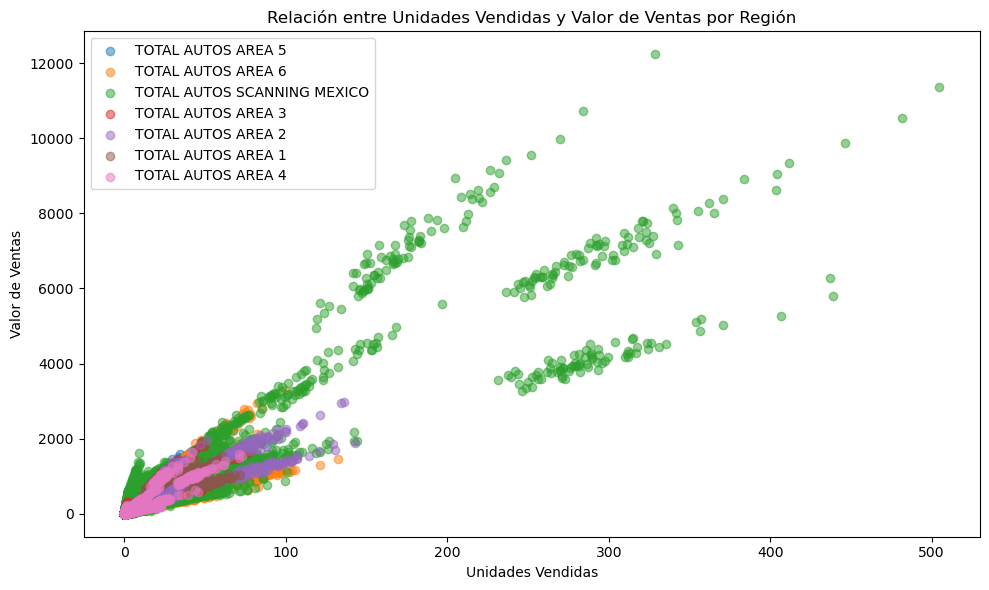

In [22]:
# Relación entre unidades vendidas y valor por región
# Permite comparar comportamientos regionales sin hacer múltiples gráficas separadas.

plt.figure(figsize=(10,6))

for reg in sales_category['REGION'].unique():
    data = sales_category[sales_category['REGION'] == reg]
    plt.scatter(data['TOTAL_UNIT_SALES'], data['TOTAL_VALUE_SALES'], alpha = 0.5, label = reg)

plt.title('Relación entre Unidades Vendidas y Valor de Ventas por Región')
plt.xlabel('Unidades Vendidas')
plt.ylabel('Valor de Ventas')
plt.legend()
plt.tight_layout()
plt.savefig('Relación_entre_Unidades_Vendidas_y_Valor_de_Ventas_por_Región.png', dpi=300, bbox_inches="tight")
plt.show()

El análisis de dispersión permitió identificar una relación positiva entre las unidades vendidas y el valor de ventas, lo que indica que un mayor volumen generalmente se traduce en mayores ingresos. Asimismo, se observaron diferencias en el comportamiento por región y en el desempeño promedio semanal, así como la presencia de algunos valores atípicos que podrían representar productos o periodos con comportamientos excepcionales. Este análisis aporta información útil para detectar oportunidades comerciales y optimizar estrategias de venta.

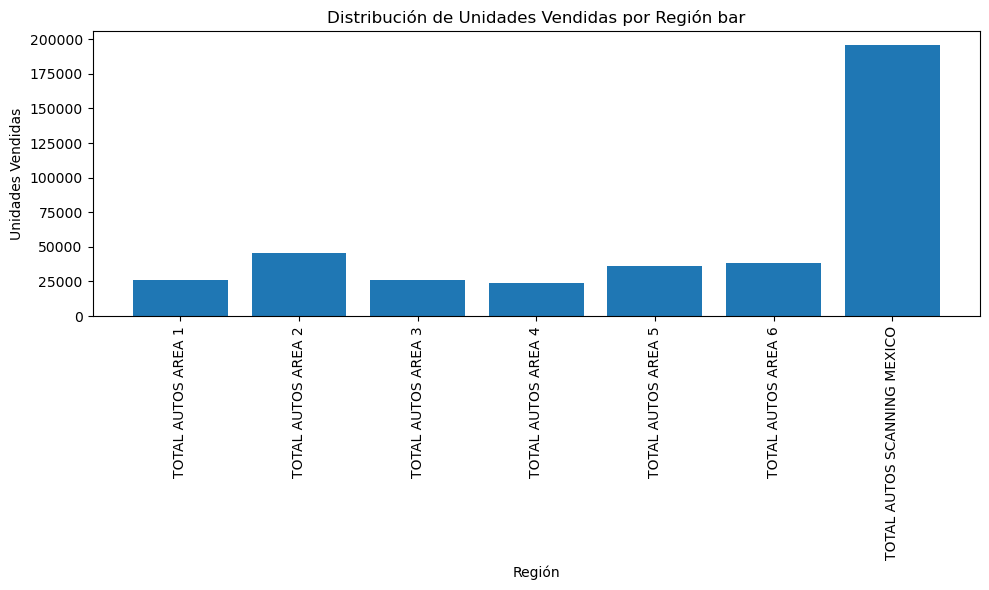

In [15]:
# 6. Visualizar la distribución geográfica de las ventas: Si es posible, utiliza mapas o gráficos de barras apiladas para visualizar las ventas por 
# región. Esto puede ayudar a identificar qué regiones tienen el mayor o menor rendimiento.

# Ventas totales por región (barras simples)
# Este gráfico muestra qué regiones generan más volumen de ventas.

# Agrupar ventas por región
sales_by_region = sales_category.groupby('REGION')['TOTAL_UNIT_SALES'].sum().reset_index()

import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))
plt.bar(sales_by_region['REGION'], sales_by_region['TOTAL_UNIT_SALES'])
plt.title('Distribución de Unidades Vendidas por Región bar')
plt.xlabel('Región')
plt.ylabel('Unidades Vendidas')
plt.xticks(rotation = 90)
plt.tight_layout()
plt.savefig('Distribución de Unidades Vendidas por Región bar.png', dpi=300, bbox_inches="tight")
plt.show()

In [16]:
import pathlib
pathlib.Path().resolve()

WindowsPath('C:/Users/980014097')

) missing from font(s) DejaVu Sans.mp\ipykernel_17024\3380166729.py:17: UserWarning: Glyph 13 (
  plt.tight_layout()
) missing from font(s) DejaVu Sans.mp\ipykernel_17024\3380166729.py:18: UserWarning: Glyph 13 (
  plt.savefig('Distribución de Ventas por Región y Categoría.png', dpi=300, bbox_inches="tight")
) missing from font(s) DejaVu Sans.te-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 13 (
  fig.canvas.print_figure(bytes_io, **kw)


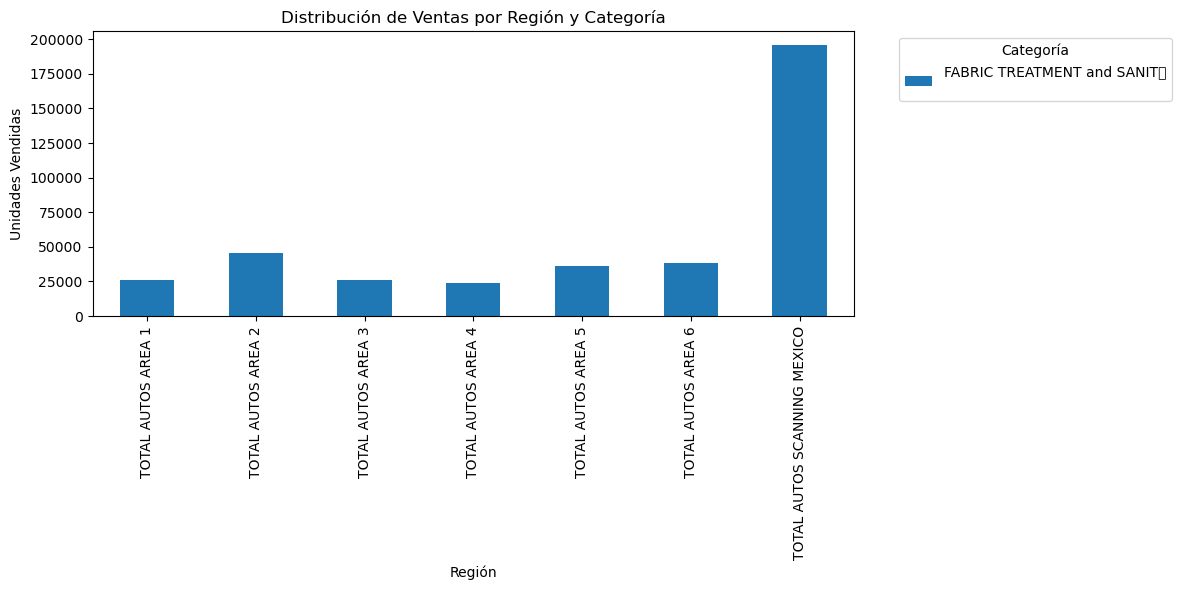

In [17]:
# Ventas por región y categoría (barras apiladas)
# Este gráfico permite ver cómo contribuye cada categoría dentro de cada región.

# Agrupar por región y categoría
sales_region_category = sales_category.groupby(['REGION', 'CATEGORY_y'])['TOTAL_UNIT_SALES'].sum().reset_index()

# Pivotear para barras apiladas
pivot_region_category = sales_region_category.pivot(index = 'REGION', columns = 'CATEGORY_y', values = 'TOTAL_UNIT_SALES')

pivot_region_category.plot(kind = 'bar', stacked = True, figsize = (12,6))

plt.title('Distribución de Ventas por Región y Categoría')
plt.xlabel('Región')
plt.ylabel('Unidades Vendidas')
plt.xticks(rotation = 90)
plt.legend(title = 'Categoría', bbox_to_anchor = (1.05, 1))
plt.tight_layout()
plt.savefig('Distribución de Ventas por Región y Categoría.png', dpi=300, bbox_inches="tight")
plt.show()


Conclusión: El análisis geográfico de las ventas evidenció diferencias claras en el desempeño entre regiones. Algunas regiones concentran un mayor volumen de ventas, mientras que otras presentan un rendimiento menor. Además, la composición de ventas por categoría varía entre regiones, lo que sugiere oportunidades para ajustar estrategias comerciales y de distribución según el comportamiento regional.

) missing from font(s) DejaVu Sans.mp\ipykernel_17024\2726054255.py:17: UserWarning: Glyph 13 (
  plt.tight_layout()
) missing from font(s) DejaVu Sans.mp\ipykernel_17024\2726054255.py:18: UserWarning: Glyph 13 (
  plt.savefig('Distribución de Unidades Vendidas por Categoría.png', dpi=300, bbox_inches="tight")


<Figure size 1000x600 with 0 Axes>

) missing from font(s) DejaVu Sans.te-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 13 (
  fig.canvas.print_figure(bytes_io, **kw)


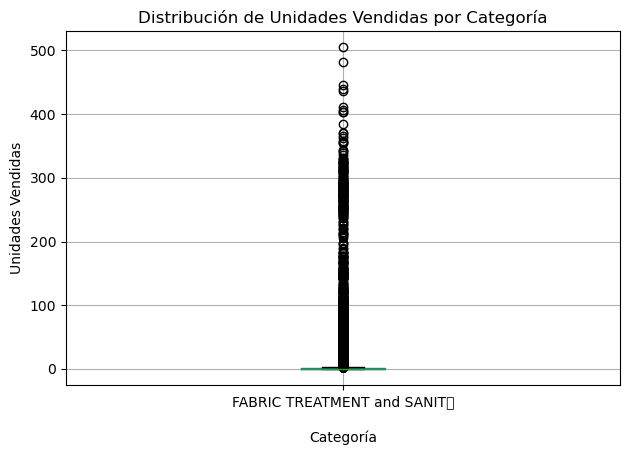

In [18]:
# 7. Identificar posibles outliers y anomalías: Utiliza gráficos de caja (boxplots) para identificar posibles outliers en los datos de ventas por 
# producto, categoría o región. Identificar outliers puede ayudar a entender mejor los patrones inusuales o anómalos en los datos.

# Outliers en unidades vendidas por categoría
# Este boxplot permite observar la dispersión de las ventas y detectar categorías con valores extremos.
# Aquí los puntos fuera de los “bigotes” representan outliers.

import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))
sales_category.boxplot(column = 'TOTAL_UNIT_SALES', by = 'CATEGORY_y')

plt.title('Distribución de Unidades Vendidas por Categoría')
plt.suptitle('')
plt.xlabel('Categoría')
plt.ylabel('Unidades Vendidas')
plt.tight_layout()
plt.savefig('Distribución de Unidades Vendidas por Categoría.png', dpi=300, bbox_inches="tight")
plt.show()

<Figure size 1000x600 with 0 Axes>

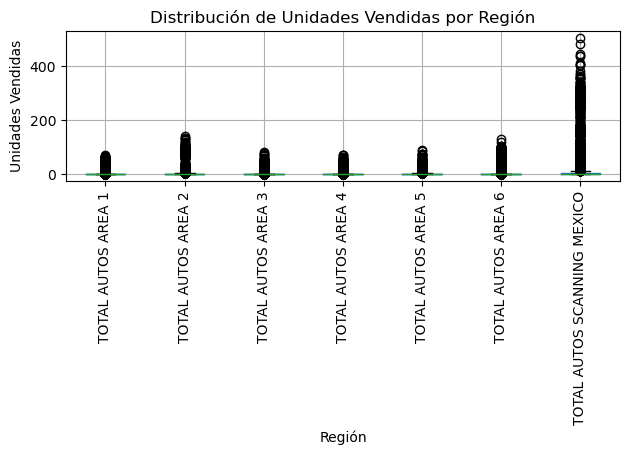

In [19]:
# Outliers en unidades vendidas por región
# Este gráfico permite identificar regiones con comportamientos anómalos.

plt.figure(figsize=(10,6))
sales_category.boxplot(column = 'TOTAL_UNIT_SALES', by = 'REGION', rot = 90)

plt.title('Distribución de Unidades Vendidas por Región')
plt.suptitle('')
plt.xlabel('Región')
plt.ylabel('Unidades Vendidas')
plt.tight_layout()
plt.savefig('Distribución de Unidades Vendidas por Región.png', dpi=300, bbox_inches="tight")
plt.show()

) missing from font(s) DejaVu Sans.mp\ipykernel_17024\3388332053.py:11: UserWarning: Glyph 13 (
  plt.tight_layout()
) missing from font(s) DejaVu Sans.mp\ipykernel_17024\3388332053.py:12: UserWarning: Glyph 13 (
  plt.savefig('Distribución del Valor de Ventas por Categoría.png', dpi=300, bbox_inches="tight")


<Figure size 1000x600 with 0 Axes>

) missing from font(s) DejaVu Sans.te-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 13 (
  fig.canvas.print_figure(bytes_io, **kw)


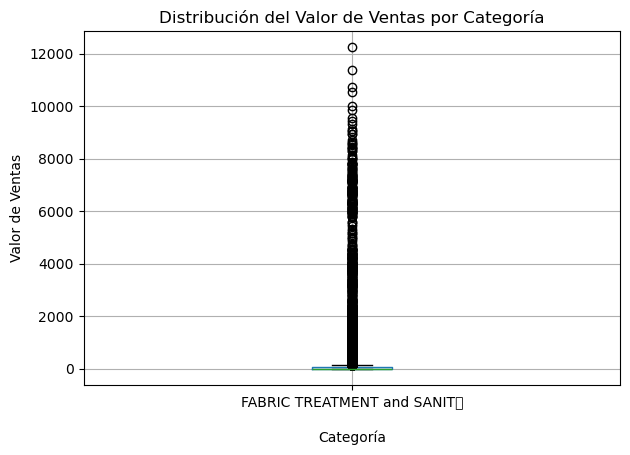

In [20]:
# Outliers en valor de ventas por categoría

plt.figure(figsize=(10,6))
sales_category.boxplot(column = 'TOTAL_VALUE_SALES', by = 'CATEGORY_y')

plt.title('Distribución del Valor de Ventas por Categoría')
plt.suptitle('')
plt.xlabel('Categoría')
plt.ylabel('Valor de Ventas')
plt.tight_layout()
plt.savefig('Distribución del Valor de Ventas por Categoría.png', dpi=300, bbox_inches="tight")
plt.show()

Conclusión: El análisis mediante gráficos de caja permitió identificar la presencia de valores atípicos en las ventas, tanto por categoría como por región. Estos outliers representan comportamientos inusuales que pueden deberse a promociones, alta demanda en periodos específicos o eventos extraordinarios. Identificar estos valores resulta clave para comprender mejor la variabilidad de las ventas y apoyar decisiones comerciales más informadas.

8. Documentar los insights obtenidos: Anota los principales hallazgos que observes en cada visualización. Por ejemplo, si ciertas categorías tienen un desempeño consistentemente alto o si ciertas regiones muestran un crecimiento o declive inesperado en las ventas.

- Distribución de ventas (Ejercicio 3)

Las ventas presentan una distribución asimétrica, donde la mayoría de los registros corresponden a volúmenes bajos, mientras que un número reducido de observaciones concentra valores altos. Esto indica que pocos productos o periodos generan una proporción significativa de las ventas totales, lo cual es consistente con un comportamiento de concentración.

- Tendencia de ventas en el tiempo (Ejercicio 4)

El análisis temporal mostró que las ventas no se mantienen constantes a lo largo del tiempo, sino que presentan variaciones y picos en determinados periodos. Al revisar por categoría y región, se observan diferencias claras en el comportamiento de ventas, lo que sugiere patrones estacionales y distintos ritmos de crecimiento entre segmentos y zonas geográficas.

- Relación entre variables (Ejercicio 5)

Los gráficos de dispersión evidencian una relación positiva entre las unidades vendidas y el valor de ventas, lo que indica que un mayor volumen generalmente se traduce en mayores ingresos. Asimismo, se identificaron algunos valores atípicos que podrían corresponder a productos de alto desempeño o eventos extraordinarios, como promociones o lanzamientos específicos.

- Distribución geográfica de las ventas (Ejercicio 6)

El análisis por región reveló diferencias significativas en el desempeño comercial. Algunas regiones concentran un mayor volumen de ventas, mientras que otras muestran un rendimiento menor. Además, la composición de ventas por categoría varía entre regiones, lo que sugiere oportunidades para estrategias comerciales diferenciadas según la zona.

- Outliers y anomalías (Ejercicio 7)

Los boxplots permitieron identificar la presencia de valores atípicos en las ventas por categoría y región. Estos outliers reflejan comportamientos inusuales que pueden estar asociados a picos de demanda, campañas promocionales o eventos específicos. Su identificación es clave para evitar interpretaciones sesgadas y para comprender mejor la variabilidad de los datos.

- Insight general

En conjunto, el análisis permitió comprender el comportamiento de las ventas desde distintas perspectivas: temporal, geográfica y por producto. Los resultados muestran una alta variabilidad en las ventas, con diferencias claras entre categorías y regiones, lo que resalta la importancia de segmentar el análisis para una mejor toma de decisiones comerciales.